In [2]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings(action='ignore')

from pypkg.pylumerical import *
from pypkg.utils import *
from tqdm.autonotebook import tqdm
import numpy as np
import pandas as pd

In [2]:
lum = Pylum(fname='mid-IR metalens demo')

In [3]:
lum.update_material_lib()

In [4]:
lum.add_struct(struct_type='circle',
               lattice='square',
                x=0, y=0,
                material='mid_IR_asiH - Hyemi')
lum.add_substrate(x=0, y=0,
                  material='MgF2_Dodge_1984')

lum.set_wavelength(lamb_st=4000*NM, lamb_ed=4000*NM, num_points=1)
data = {'diameter' : np.linspace(200*NM, 1.5*UM, 80, endpoint=True),
        'material' : [('mid_IR_asiH - Hyemi', 'MgF2_Dodge_1984')],
       'period' : np.linspace(2*UM, 2*UM, 1, endpoint=True),
       'height' : [2*UM]}
lum.set_sweep_params(data=data)

In [5]:
lum.add_planewave(inj_axis='z-axis',
             direc='Forward',
             pol_angle=0, phase=0,
             x=0, y=0, z=-200*NM)
lum.add_transmission_monitor(mtype='2D Z-normal',
            ov_glob_m=1,
            iswlinspace=1,
            issrclim=1,
            x=0, y=0)
lum.add_reflection_monitor(mtype='2D Z-normal',
            ov_glob_m=1,
            iswlinspace=1,
            issrclim=1,
            x=0, y=0)
lum.set_FDTD(dim='3D',
        xlb='Periodic', xub='Periodic',
        ylb='Periodic', yub='Periodic',
        zlb='PML', zub='PML',
        x=0, y=0,
        mesh_type='auto non-uniform',
        mesh_acc=2,
        dt_stb_factor=0.95,
        sim_time=1000e-14,
        auto_shut_min=0.5e-4)
lum.simul_span_params(FDTD_height_offset=0.5*UM,
                       source_depth=None,
                       substrate_depth=None,
                       T_monitor_height=None,
                       R_monitor_depth=None,
                      far_field_height=100*UM)

In [6]:
lum.screening()

0it [00:00, ?it/s]

  0%|          | 0/80 [00:00<?, ?it/s]

In [9]:
rr = LoadPickle('mid-IR metalens demo_phase_material_00_mid_IR_asiH - Hyemi_MgF2_Dodge_1984.pickle')

In [10]:
rr.head()

,diameter,period,height,diameter_idx,period_idx,height_idx,wavelength_idx,wavelength,reflection,transmission,Ex,nEx,Ey,nEy
0,2.000000e-07,0.000002,0.000002,0,0,0,0,0.000004,0.009929,0.977598,0.004159-0.010918j,1.022199-0.118045j,-1.918780e-12+4.156747e-12j,-1.482812e+12-1.192833e+12j
1,2.164557e-07,0.000002,0.000002,1,0,0,0,0.000004,0.009931,0.977607,0.004191-0.010906j,1.022540-0.115109j,4.655695e-12+1.154529e-11j,-5.125131e+12+7.135190e+11j
2,2.329114e-07,0.000002,0.000002,2,0,0,0,0.000004,0.009934,0.977619,0.004231-0.010891j,1.022968-0.111313j,4.435407e-12-8.177903e-12j,2.850674e+12+2.613085e+12j
3,2.493671e-07,0.000002,0.000002,3,0,0,0,0.000004,0.009942,0.977628,0.004268-0.010876j,1.023349-0.107813j,2.155173e-13-5.284540e-12j,2.109322e+12+6.196721e+11j
4,2.658228e-07,0.000002,0.000002,4,0,0,0,0.000004,0.010008,0.977618,0.004321-0.010855j,1.023860-0.102819j,2.662245e-12-1.875948e-12j,4.881019e+11+1.262704e+12j


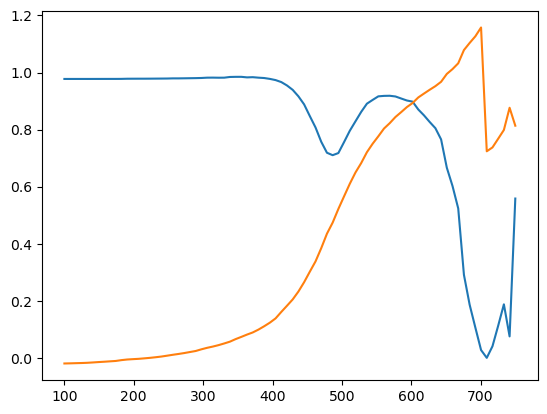

In [34]:
plt.plot(rr.diameter/2*1e9, rr.transmission)
plt.plot(rr.diameter/2*1e9, np.unwrap(np.angle(rr.nEx))/(np.pi*2))

In [3]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings(action='ignore')

from pypkg.pylumerical import *
from pypkg.utils import *
from tqdm.autonotebook import tqdm
import numpy as np
import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
lum = lumapi.FDTD()

In [6]:
ak = lum.load('C:/Users/spruce/Desktop/Ag-Si_Hyperlens_532nm.fsp')

In [ ]:
aa = lum.getsweepresult("sweep_num_layer", "Transmission")

In [10]:
aa = lum.getsweepdata("sweep_num_layer")

In [14]:
sweep_params = aa.split('\n')

In [15]:
sweep_params

['Field_inner_side',
 'Transmission',
 'Z_profile',
 'Power_inner_side',
 'Z_porfile_scale',
 'Inner_scale',
 'num_layer',
 'Inner_radius']

In [18]:
bb = lum.getsweepresult('sweep_num_layer', sweep_params[0])

In [20]:
bb = lum.getsweepdata('sweep_num_layer', sweep_params[0])

In [21]:
bb

array([[[2.45389495e+02, 2.74424590e+02, 4.21668186e+02, ...,
         7.12440005e+01, 6.18501779e+01, 5.09514418e+01],
        [2.41352667e+02, 3.06126018e+02, 4.10918054e+02, ...,
         6.19858505e+01, 5.45588537e+01, 4.63984963e+01],
        [2.43424023e+02, 3.33705027e+02, 4.12454724e+02, ...,
         5.32348709e+01, 4.72100946e+01, 4.19778072e+01],
        ...,
        [3.36182717e+01, 3.20976724e+01, 1.79580913e+01, ...,
         6.64466145e+00, 5.70329181e+00, 5.55929977e+00],
        [3.23000619e+01, 2.99780261e+01, 1.51304549e+01, ...,
         6.27242686e+00, 5.35198372e+00, 5.17175983e+00],
        [2.96852378e+01, 2.57302922e+01, 1.29060803e+01, ...,
         6.04225230e+00, 5.12020792e+00, 5.00160213e+00]],

       [[1.96624228e+02, 1.94847178e+02, 1.90464565e+02, ...,
         4.04449242e+01, 3.71249087e+01, 2.68396368e+01],
        [1.80867528e+02, 1.97116530e+02, 1.64914680e+02, ...,
         3.25950197e+01, 3.06569619e+01, 2.27983860e+01],
        [1.75467333e+02, 